#  Notebook 1 — Data Cleaning

## Context
This project is based on a dataset of insurance customer reviews from various French
insurance companies, spread across 35 Excel files. Each review exists in two versions 
the original in **French** and its **English translation**  giving us flexibility
depending on the NLP task and model we use.

## Objective
The goal of this notebook is to build a clean, unified dataset that will serve as the
foundation for all subsequent NLP tasks. Raw reviews may contain typos, duplicates, and
inconsistent formatting, so proper cleaning is essential before any modeling can begin.

## In this notebook we will:
- Load and merge all 35 Excel files into one dataset
- Explore the basic structure of the data
- Handle missing values and duplicates
- Perform spelling correction on the French reviews
- Save the cleaned dataset as a CSV file


IMPORT ALL NECESSARY LIBRAIRES FOR THE PROJECT.

In [1]:

import pandas as pd
import numpy as np
import glob
import os
import re
from pathlib import Path
from spellchecker import SpellChecker
from tqdm.auto import tqdm

tqdm.pandas()

## Step 1 — Initial Data Exploration
Her we will first explore a few individual files to understand
their structure, columns, and content. This helps us verify that all files share
the same format before combining them into one dataset.

In [10]:
data_folder = Path("/Users/dovila/Downloads/Traduction avis clients")
files = sorted([f for f in data_folder.glob("*.xlsx") if f.name.startswith("avis")])
print(f"Found {len(files)} files\n")

# Load and display the first 4 files individually
first_review = pd.read_excel(files[0])
print(f" {files[0].name}")
first_review.head()

Found 35 files

 avis_10_traduit.xlsx


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,4,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN
1,4,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN
2,1,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN
3,1,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,03/03/2020,01/03/2020,The GMF has been waiting for a water damage fo...,NaN,NaN
4,3,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,28/08/2021,01/08/2021,I am good with this insurance. She is practica...,NaN,NaN


In [11]:
second_review = pd.read_excel(files[1])
print(f" {files[1].name}")
second_review.head()

 avis_11_traduit.xlsx


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1,shanonmercadier-43885,"si vous voulez être pris pour une courge , ou ...",Pacifica,auto,train,02/03/2017,01/03/2017,"If you want to be taken for a squash, or a sim...",NaN,NaN
1,1,mali-97585,reponds pas au telephone\nespace client ne mar...,Mercer,sante,train,18/09/2020,01/09/2020,do not respond to the phone\nCustomer area doe...,NaN,NaN
2,4,vincent-g-127256,"je suis satisfait du prix et services, la déma...",Direct Assurance,auto,train,09/08/2021,01/08/2021,"I am satisfied with the price and services, th...",NaN,NaN
3,5,aurore-c-105883,.simple pratique et reactif pour etablir des d...,Zen'Up,credit,train,08/03/2021,01/03/2021,. Practical and reactive to establish quotes\n...,NaN,NaN
4,5,edgard-s-128749,assez simple d'utilisation facile et rapide re...,AMV,moto,train,20/08/2021,01/08/2021,Quite easy to use easy and quick use recommend...,NaN,NaN


In [12]:
second_review = pd.read_excel(files[1])
print(f" {files[2].name}")
second_review.head()

 avis_12_traduit.xlsx


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1,shanonmercadier-43885,"si vous voulez être pris pour une courge , ou ...",Pacifica,auto,train,02/03/2017,01/03/2017,"If you want to be taken for a squash, or a sim...",NaN,NaN
1,1,mali-97585,reponds pas au telephone\nespace client ne mar...,Mercer,sante,train,18/09/2020,01/09/2020,do not respond to the phone\nCustomer area doe...,NaN,NaN
2,4,vincent-g-127256,"je suis satisfait du prix et services, la déma...",Direct Assurance,auto,train,09/08/2021,01/08/2021,"I am satisfied with the price and services, th...",NaN,NaN
3,5,aurore-c-105883,.simple pratique et reactif pour etablir des d...,Zen'Up,credit,train,08/03/2021,01/03/2021,. Practical and reactive to establish quotes\n...,NaN,NaN
4,5,edgard-s-128749,assez simple d'utilisation facile et rapide re...,AMV,moto,train,20/08/2021,01/08/2021,Quite easy to use easy and quick use recommend...,NaN,NaN


In [13]:
fourth_review = pd.read_excel(files[3])
print(f" {files[3].name}")
fourth_review.head()

 avis_13_traduit.xlsx


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,3,txingi-137669,Ayant des difficultés pour transmettre un doc...,Santiane,sante,train,18/10/2021,01/10/2021,Having difficulty sending a document for a re...,NaN,NaN
1,3,edouard-s-106206,Je suis satisfait du niveau d’assurance garant...,Direct Assurance,auto,train,11/03/2021,01/03/2021,I am satisfied with the level of insurance gua...,NaN,NaN
2,1,ben-69783,Aucun remboursement depuis octobre 2017. Aprés...,APRIL,sante,train,31/12/2018,01/12/2018,No reimbursement since October 2017. After ask...,NaN,NaN
3,4,pmkuma-91489,"Je suis satisfait du service de devis, simple ...",Direct Assurance,auto,train,18/06/2020,01/06/2020,"I am satisfied with the quote service, simple ...",NaN,NaN
4,1,rochon-97382,Dans mon contrat d assurance auto il est conve...,GMF,auto,train,14/09/2020,01/09/2020,In my car insurance contract it is agreed a lo...,NaN,NaN


From the 4th dataset, it is clearly seen that the various datasets have similarities so we are going to concatenate those datasets as there are 35 of them so we can have just have one dataset at the end of the day.

In [14]:
# Load and concatenate all 35 files
dfs = [pd.read_excel(f) for f in tqdm(files, desc="Loading files")]
df = pd.concat(dfs, ignore_index=True)

print(f" All files concatenated!")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
df.head()

Loading files:   0%|          | 0/35 [00:00<?, ?it/s]

 All files concatenated!
Total rows: 34435
Total columns: 11


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,03/03/2020,01/03/2020,The GMF has been waiting for a water damage fo...,NaN,NaN
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,28/08/2021,01/08/2021,I am good with this insurance. She is practica...,NaN,NaN


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24104 non-null  float64
 1   auteur            34434 non-null  str    
 2   avis              34435 non-null  str    
 3   assureur          34435 non-null  str    
 4   produit           34435 non-null  str    
 5   type              34435 non-null  str    
 6   date_publication  34435 non-null  str    
 7   date_exp          34435 non-null  str    
 8   avis_en           34433 non-null  str    
 9   avis_cor          435 non-null    object 
 10  avis_cor_en       431 non-null    object 
dtypes: float64(1), object(2), str(8)
memory usage: 2.9+ MB


## Step 3 — Data Types & Basic Cleaning
We fix the data types and handle missing values before moving on to text cleaning.

We can change the date_publication and date_exp data type to date since that is required data type for such.

In [16]:
# Fix date columns
df['date_publication'] = pd.to_datetime(df['date_publication'], format="%d/%m/%Y")
df['date_exp'] = pd.to_datetime(df['date_exp'], format="%d/%m/%Y")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   note              24104 non-null  float64       
 1   auteur            34434 non-null  str           
 2   avis              34435 non-null  str           
 3   assureur          34435 non-null  str           
 4   produit           34435 non-null  str           
 5   type              34435 non-null  str           
 6   date_publication  34435 non-null  datetime64[us]
 7   date_exp          34435 non-null  datetime64[us]
 8   avis_en           34433 non-null  str           
 9   avis_cor          435 non-null    object        
 10  avis_cor_en       431 non-null    object        
dtypes: datetime64[us](2), float64(1), object(2), str(6)
memory usage: 2.9+ MB


Next will be removing duplicates and missing values

In [17]:
# Check and remove duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"New shape: {df.shape}")

Number of duplicate rows: 5
New shape: (34430, 11)


As part of the data cleaning process, duplicated rows were identified and removed from the dataset. A total of 5 duplicate entries were found. These duplicates were deleted in order to avoid over-representing repeated reviews and to improve the reliability of the analysis and the later modeling steps.

**Empty reviews**

In [18]:
# Check for empty reviews
empty_reviews = df["avis"].isna().sum() + (df["avis"].astype(str).str.strip() == "").sum()
print("Number of empty reviews:", empty_reviews)

empty_reviews_en = df["avis_en"].isna().sum() + (df["avis_en"].astype(str).str.strip() == "").sum()
print("Number of empty English reviews:", empty_reviews_en)

Number of empty reviews: 0
Number of empty English reviews: 2


My next move was to check if there are empty reviews or not so it could be deleted but it was empty in french but not in english

In [19]:
# Drop rows where the review text is missing
df = df.dropna(subset=['avis', 'avis_en']).reset_index(drop=True)
# Drop the avis_cor and avis_cor_en columns as we will redo them properly
df = df.drop(columns=['avis_cor', 'avis_cor_en'])
print(f"New shape: {df.shape}")
df.isnull().sum()

New shape: (34428, 9)


note                10329
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 0
dtype: int64

### ***SPELLING CORRECTION***
The idea here is to write a function that permits us to cancel all typo errors , problems with symbols punctuation etc...

In [21]:
from spellchecker import SpellChecker
spell = SpellChecker(language="fr")
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["avis_clean"] = df["avis"].apply(clean_text)
print("Text cleaned!")
df[["avis", "avis_clean"]].head(5)

Text cleaned!


,avis,avis_clean
0,La personne au téléphone était Clair et sympat...,la personne au téléphone était clair et sympat...
1,"Satisfait.\n\nRéactivité, simplicité. Prix att...",satisfait réactivité simplicité prix attractif...
2,"Assureur à fuir, n assure pas ses responsabili...",assureur à fuir n assure pas ses responsabilit...
3,Voilà 3 mois que la GMF me fait attendre pour ...,voilà mois que la gmf me fait attendre pour un...
4,Je suis bien avec cet assurance.elle est prati...,je suis bien avec cet assurance elle est prati...


In [22]:
# Build correction dictionary from unique words
def get_correction_map(series):
    all_words = set(" ".join(series.dropna().astype(str)).split())
    print(f"Total unique words: {len(all_words)}")
    
    misspelled = list(spell.unknown(all_words))
    print(f"Misspelled words found: {len(misspelled)}")
    
    correction_map = {}
    for word in tqdm(misspelled, desc="Building correction map"):
        corr = spell.correction(word)
        if corr is not None:
            correction_map[word] = corr
    return correction_map

corr_dict = get_correction_map(df["avis_clean"])
print("Correction map built sucessfully!")

Total unique words: 35086
Misspelled words found: 13559


Building correction map:   0%|          | 0/13559 [00:00<?, ?it/s]

Correction map built sucessfully!


In [23]:
# Apply corrections
def apply_correction(text):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    words = str(text).split()
    return " ".join([corr_dict.get(w, w) for w in words])

df["avis_cor"] = df["avis_clean"].progress_apply(apply_correction)
df[["avis", "avis_clean", "avis_cor"]].head(5)

  0%|          | 0/34428 [00:00<?, ?it/s]

,avis,avis_clean,avis_cor
0,La personne au téléphone était Clair et sympat...,la personne au téléphone était clair et sympat...,la personne au téléphone était clair et sympat...
1,"Satisfait.\n\nRéactivité, simplicité. Prix att...",satisfait réactivité simplicité prix attractif...,satisfait réactivité simplicité prix attractif...
2,"Assureur à fuir, n assure pas ses responsabili...",assureur à fuir n assure pas ses responsabilit...,assureur à fuir un assure pas ses responsabili...
3,Voilà 3 mois que la GMF me fait attendre pour ...,voilà mois que la gmf me fait attendre pour un...,voilà mois que la me me fait attendre pour un ...
4,Je suis bien avec cet assurance.elle est prati...,je suis bien avec cet assurance elle est prati...,je suis bien avec cet assurance elle est prati...


## Highlighting Frequent Words & N-grams
In this step we analyze the most frequently occurring words and word sequences
in the reviews. This helps us understand the main themes and topics discussed
by customers, and gives us a first insight into the structure of the corpus.
We analyze unigrams (single words), bigrams (2-word sequences) and trigrams
(3-word sequences) after removing French stopwords.

In [26]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dovila/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /Users/dovila/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [27]:
from collections import Counter
from nltk.corpus import stopwords
from nltk.util import ngrams
import matplotlib.pyplot as plt

stop_fr = set(stopwords.words("french"))

# Tokenize corrected French reviews
texts = df["avis_cor"].dropna().astype(str)

all_tokens = []
for text in texts:
    tokens = [
        w for w in text.split()
        if w not in stop_fr and len(w) > 2 and w.isalpha()
    ]
    all_tokens.extend(tokens)

print(f"Total tokens: {len(all_tokens)}")

Total tokens: 1037206


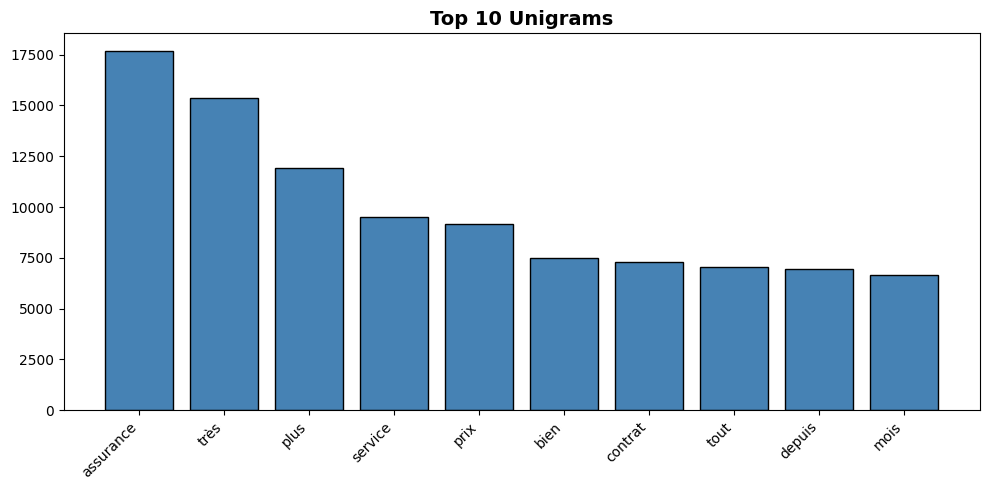

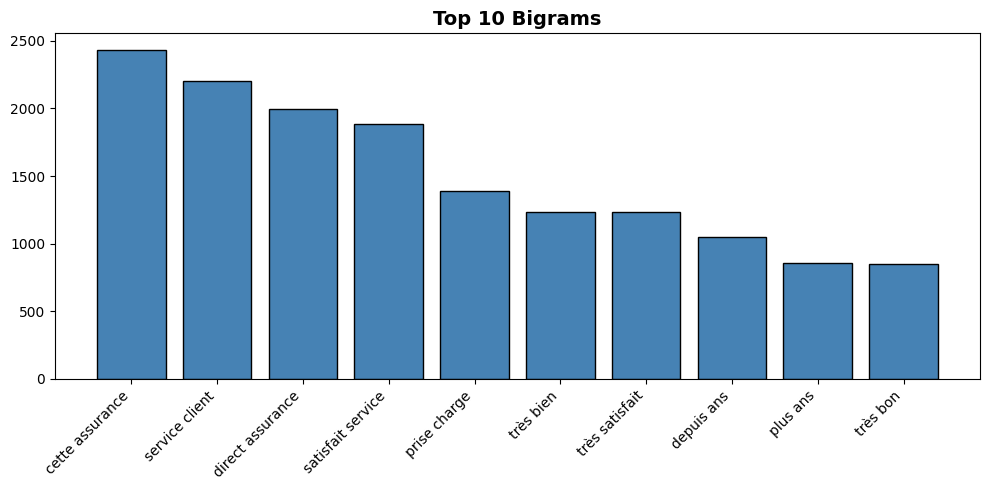

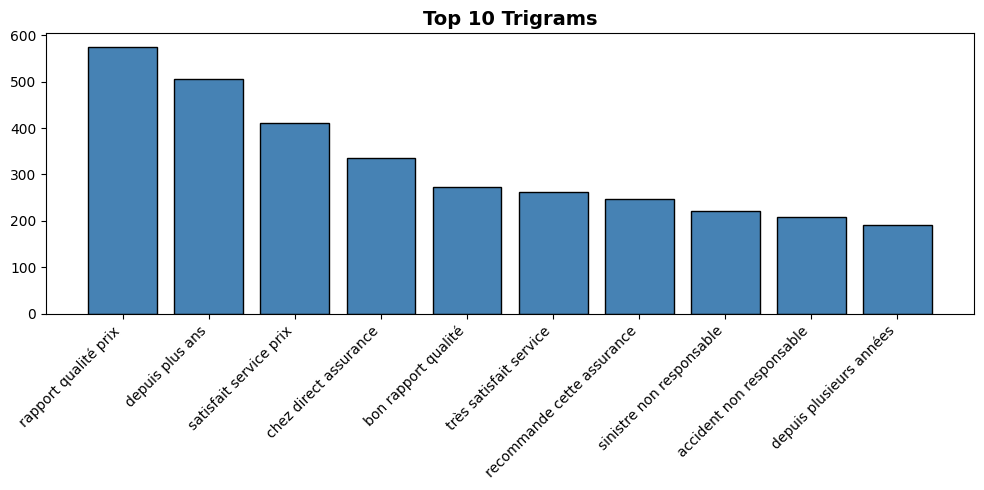

In [28]:
def plot_ngrams(tokens, n=1, top_k=10, title="Top n-grams"):
    if n == 1:
        common = Counter(tokens).most_common(top_k)
    else:
        n_grams = list(ngrams(tokens, n))
        common = Counter(n_grams).most_common(top_k)
        common = [(" ".join(k), v) for k, v in common]

    labels, counts = zip(*common)

    plt.figure(figsize=(10, 5))
    plt.bar(labels, counts, color="steelblue", edgecolor="black")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_ngrams(all_tokens, n=1, title="Top 10 Unigrams")
plot_ngrams(all_tokens, n=2, title="Top 10 Bigrams")
plot_ngrams(all_tokens, n=3, title="Top 10 Trigrams")

### Interpretation of frequent words and n-grams

The unigram, bigram, and trigram analysis helps us understand the most common words and expressions used in the reviews. The most frequent terms show that customers often talk about insurance, service, price, and contracts. This suggests that these are some of the main topics in the dataset.

The trigram results are especially useful because they give more context than single words. For example, expressions like *rapport qualité prix* and *bon rapport qualité* show that many reviews discuss value for money. Other expressions such as *recommande cette assurance* suggest positive customer opinions, while terms like *sinistre non responsable* and *accident non responsable* show that claim-related situations are also important in the reviews.

Overall, this analysis gives a first idea of the main themes in the corpus. It will be useful for the next parts of the project, especially topic detection, sentiment analysis, and supervised learning.

## Saving the Cleaned Dataset
We save the cleaned dataset as a CSV file so it can be easily reused
in all subsequent notebooks without having to redo the cleaning steps.

In [29]:
df.to_csv("cleaned_dataset.csv", index=False)
print(" Dataset saved ")
print(f"Final shape: {df.shape}")
df.head()

 Dataset saved 
Final shape: (34428, 11)


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_clean,avis_cor
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,2021-10-06,2021-10-01,The person on the phone was clear and friendly...,la personne au téléphone était clair et sympat...,la personne au téléphone était clair et sympat...
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,2021-07-09,2021-07-01,"Satisfied.\n\nReactivity, simplicity. Attracti...",satisfait réactivité simplicité prix attractif...,satisfait réactivité simplicité prix attractif...
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,2020-10-15,2020-10-01,"Insurer to flee, does not ensure its responsib...",assureur à fuir n assure pas ses responsabilit...,assureur à fuir un assure pas ses responsabili...
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,2020-03-03,2020-03-01,The GMF has been waiting for a water damage fo...,voilà mois que la gmf me fait attendre pour un...,voilà mois que la me me fait attendre pour un ...
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,2021-08-28,2021-08-01,I am good with this insurance. She is practica...,je suis bien avec cet assurance elle est prati...,je suis bien avec cet assurance elle est prati...
